In [1]:
pip install pandas numpy matplotlib seaborn plotly

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
df = pd.read_csv("sales_data (1).csv")

In [4]:
print(df.head())

print(df.info())

print(df.describe())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None
         Quantity      

In [5]:
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
sns.set_style("whitegrid")

sns.set_palette("Blues")

plt.rcParams['figure.figsize'] = (10,6)

In [7]:
print("========== KPI SUMMARY ==========")

print("Total Sales:", df['Total_Sales'].sum())

print("Average Sales:", df['Total_Sales'].mean())

print("Top Product:",
      df.groupby('Product')['Total_Sales'].sum().idxmax())

print("Top Region:",
      df.groupby('Region')['Total_Sales'].sum().idxmax())

========== KPI SUMMARY ==========
Total Sales: 12365048
Average Sales: 123650.48
Top Product: Laptop
Top Region: North


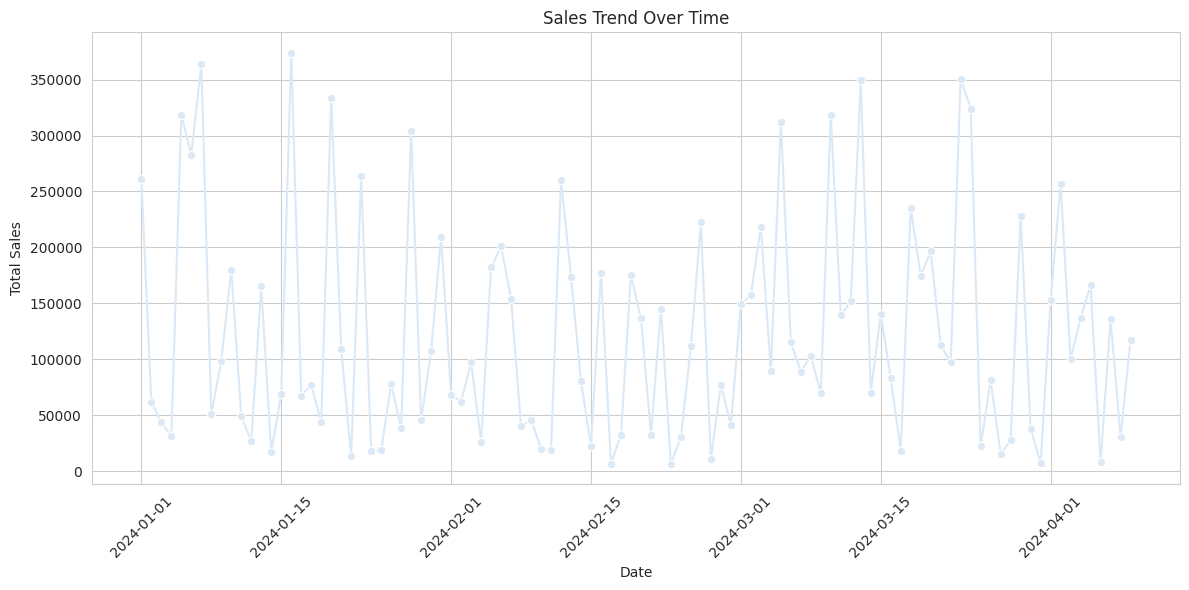

In [8]:
sales_trend = df.groupby('Date')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Total_Sales',
    data=sales_trend,
    marker='o'
)

plt.title('Sales Trend Over Time')

plt.xlabel('Date')

plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

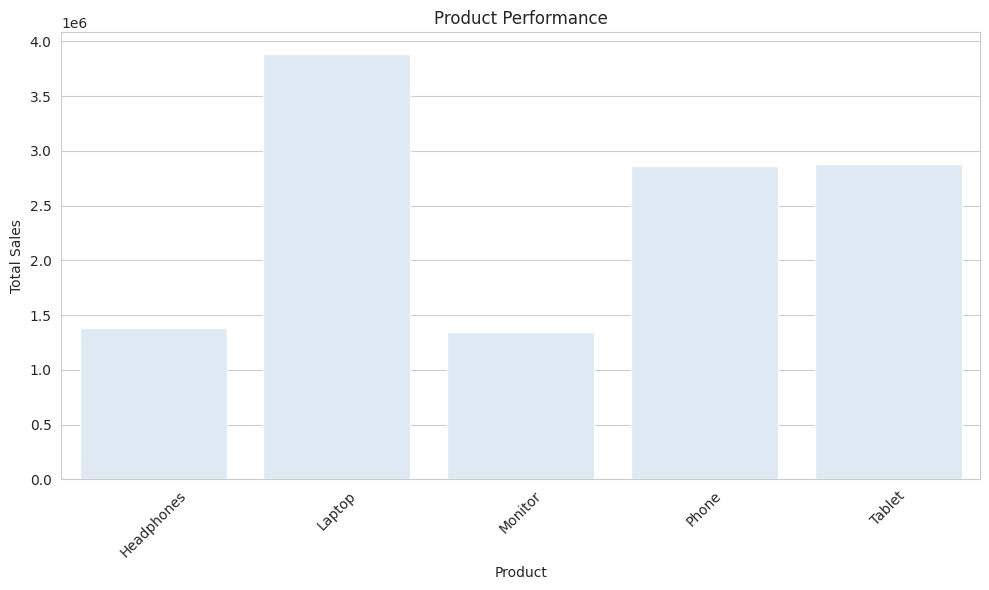

In [9]:
product_sales = df.groupby('Product')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    x='Product',
    y='Total_Sales',
    data=product_sales
)

plt.title('Product Performance')

plt.xlabel('Product')

plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

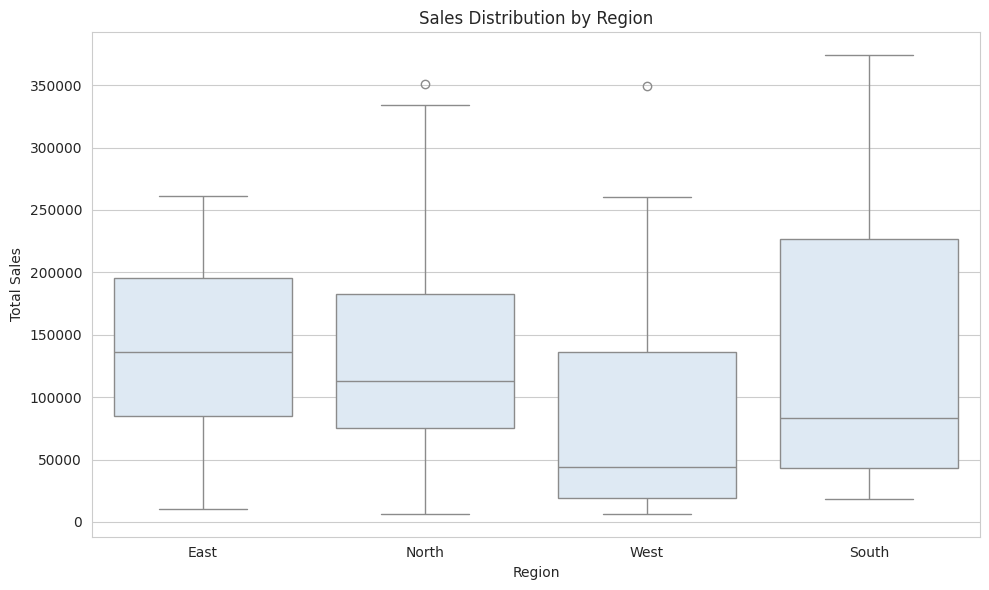

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Region',
    y='Total_Sales',
    data=df
)

plt.title('Sales Distribution by Region')

plt.xlabel('Region')

plt.ylabel('Total Sales')

plt.tight_layout()

plt.show()

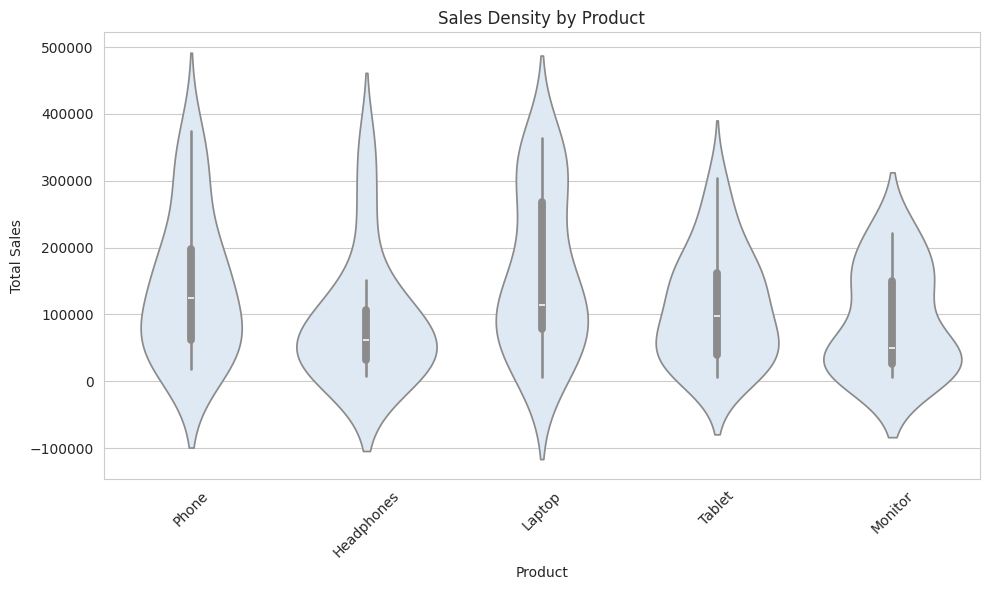

In [11]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Product',
    y='Total_Sales',
    data=df
)

plt.title('Sales Density by Product')

plt.xlabel('Product')

plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

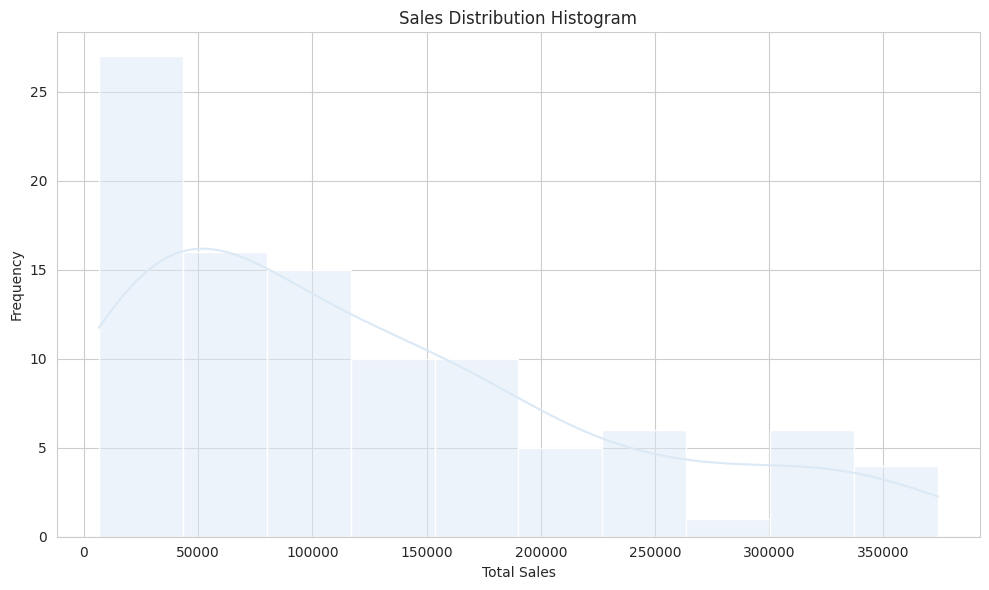

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Total_Sales'],
    bins=10,
    kde=True
)

plt.title('Sales Distribution Histogram')

plt.xlabel('Total Sales')

plt.ylabel('Frequency')

plt.tight_layout()

plt.show()

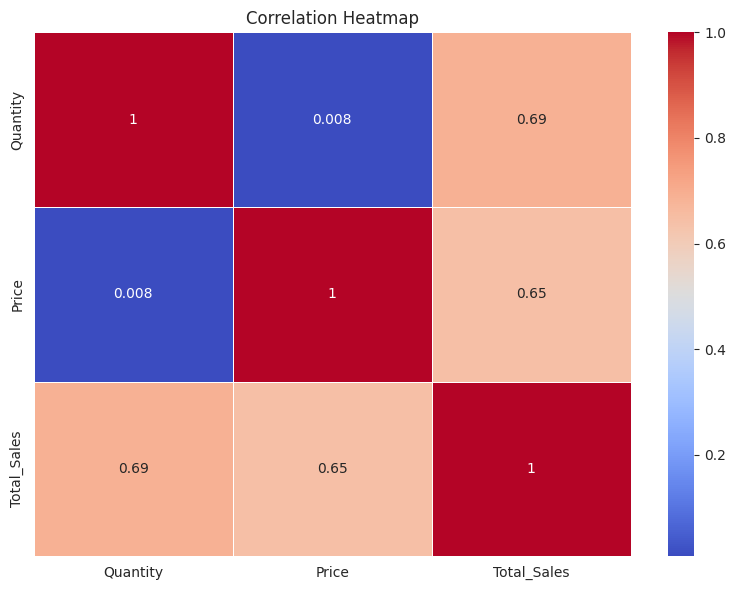

In [13]:
numeric_df = df[['Quantity', 'Price', 'Total_Sales']]

correlation = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.tight_layout()

plt.show()

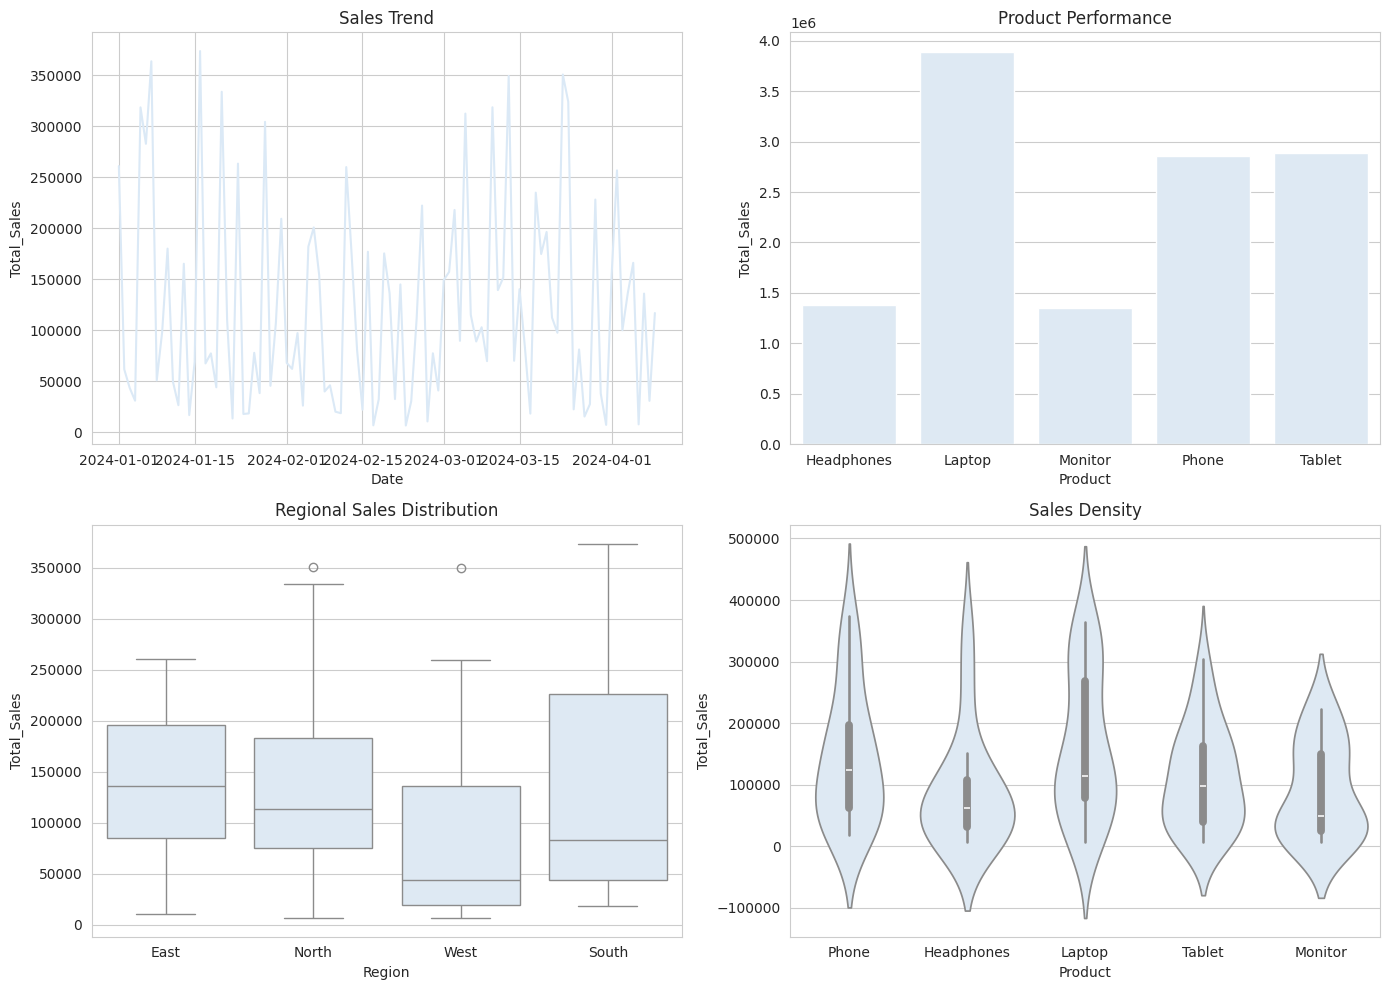

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Line Chart
sns.lineplot(
    x='Date',
    y='Total_Sales',
    data=sales_trend,
    ax=axes[0,0]
)

axes[0,0].set_title('Sales Trend')

# Bar Chart
sns.barplot(
    x='Product',
    y='Total_Sales',
    data=product_sales,
    ax=axes[0,1]
)

axes[0,1].set_title('Product Performance')

# Box Plot
sns.boxplot(
    x='Region',
    y='Total_Sales',
    data=df,
    ax=axes[1,0]
)

axes[1,0].set_title('Regional Sales Distribution')

# Violin Plot
sns.violinplot(
    x='Product',
    y='Total_Sales',
    data=df,
    ax=axes[1,1]
)

axes[1,1].set_title('Sales Density')

plt.tight_layout()

plt.show()

In [15]:
fig = px.scatter(
    df,
    x='Quantity',
    y='Total_Sales',
    color='Product',
    size='Price',
    hover_data=['Region', 'Customer_ID'],
    title='Interactive Sales Analysis'
)

fig.show()

In [16]:
fig = px.bar(
    product_sales,
    x='Product',
    y='Total_Sales',
    color='Product',
    title='Interactive Product Sales'
)

fig.show()

In [17]:
region_sales = df.groupby('Region')['Total_Sales'].sum().reset_index()

fig = px.pie(
    region_sales,
    names='Region',
    values='Total_Sales',
    title='Regional Sales Distribution'
)

fig.show()

In [18]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Sales Trend',
        'Product Sales',
        'Sales Distribution',
        'Sales vs Quantity'
    )
)

# Sales Trend
fig.add_trace(
    go.Scatter(
        x=sales_trend['Date'],
        y=sales_trend['Total_Sales'],
        mode='lines+markers',
        name='Sales Trend'
    ),
    row=1,
    col=1
)

# Product Sales
fig.add_trace(
    go.Bar(
        x=product_sales['Product'],
        y=product_sales['Total_Sales'],
        name='Product Sales'
    ),
    row=1,
    col=2
)

# Sales Distribution
fig.add_trace(
    go.Box(
        y=df['Total_Sales'],
        name='Sales Distribution'
    ),
    row=2,
    col=1
)

# Scatter Plot
fig.add_trace(
    go.Scatter(
        x=df['Quantity'],
        y=df['Total_Sales'],
        mode='markers',
        name='Sales vs Quantity'
    ),
    row=2,
    col=2
)

fig.update_layout(
    height=800,
    width=1200,
    title_text='Interactive Sales Dashboard',
    showlegend=False
)

fig.show()

In [19]:
plt.savefig("dashboard_chart.png")

<Figure size 1000x600 with 0 Axes>

In [20]:
print("===================================")

print("Interactive Sales Dashboard Created")

print("===================================")

Interactive Sales Dashboard Created
